# Jacobsville Formation ca. 990 Ma paleomagnetic pole

## Geologic context

The Jacobsville Formation is a red-bed sandstone unit exposed along the south
shore of Lake Superior. It is the youngest clastic unit associated with the
Midcontinent Rift basin, deposited after rift magmatism and post-dating the
Oronto Group (Nonesuch and Freda formations). Its deposition records Laurentia's
position in the late Tonian, after the rapid late-Mesoproterozoic plate motion
recorded by the Keweenawan Track had ended, providing a key constraint for
tracking Rodinia into the Neoproterozoic (Zhang et al., 2024).

This notebook recreates the Jacobsville pole from the site (specimen) level
following Zhang et al. (2024). The pole is computed from the archived
high-temperature detrital-hematite directions across the sampled sections, an
inclination-shallowing correction is determined with the elongation/inclination
(E/I) method, and the pole is reported in the inclination-corrected reverse
(southern-hemisphere) convention used by Zhang et al. (2024).

## Paleomagnetic and rock magnetic data

The characteristic remanence is a detrital remanent magnetization (DRM) carried
by **detrital hematite**, isolated as a high-unblocking-temperature component
(`hdt`; up to ~689 °C, near the hematite Néel temperature) by high-resolution
stepwise thermal demagnetization and PCA. A mid-/lower-unblocking-temperature
component carried by pigmentary hematite is a chemical remanent magnetization
(CRM, `hct`) removed by ~640–655 °C. Both normal (westerly) and reverse
(easterly) polarities are present. The pole here uses the `hdt` DRM directions in
tilt-corrected coordinates from the sampled sections (Agate Falls, Hammel Creek,
Dover Creek, Natural Wall, Snake Creek), n ≈ 307 specimen readings.

## Inclination-shallowing correction

Because detrital hematite acquires a shallowed inclination, the elongation/
inclination (E/I) method of Tauxe & Kent (2004) is applied (`ipmag.find_ei`):
the corrected inclination is the one whose directional distribution elongation
matches the TK03.GAD field model. This yields a flattening factor **f ≈ 0.64**
(Zhang et al., 2024). The corrected pole's confidence is reported by Zhang et al.
(2024) as a Kent ellipse (ζ95 = 4.1°, η95 = 3.1°) propagated with the Monte
Carlo approach of Pierce et al. (2022); since the Nordic format stores a single
A95, the equal-area circular approximation `sqrt(zeta95*eta95)` is used there.

## Age constraints

- Best estimate **ca. 990 Ma**. The maximum depositional age is constrained by
  CA-ID-TIMS detrital-zircon dates of 1003.21 ± 2.23 Ma (Agate Falls) and
  992.51 ± 0.64 Ma (Sandstone Creek; Hodgin et al., 2022). A minimum age comes
  from U-Pb calcite (985.5 ± 35.8 Ma) in Keweenaw Fault breccia and from
  Rigolet-phase Grenvillian deformation (ca. 1010–980 Ma; Hodgin et al., 2022).
  The full plausible range (1000–980 Ma) falls within ± 15 Ma of ca. 990 Ma.

## References

### Paleomagnetism

- Zhang, Y., Hodgin, E. B., Alemu, T., Pierce, J., Fuentes, A., & Swanson-Hysell, N. L. (2024). Tracking Rodinia into the Neoproterozoic: new paleomagnetic constraints from the Jacobsville Formation. *Tectonics*, 43, e2023TC007866. https://doi.org/10.1029/2023TC007866

### Geochronology

- Hodgin, E. B., Swanson-Hysell, N. L., Kylander-Clark, A. R. C., et al. (2022). Final inversion of the Midcontinent Rift during the Rigolet phase of the Grenvillian orogeny. *Geology*, 50(5), 547–551. https://doi.org/10.1130/G49439.1

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Specimen-level data and section selection

Data come from the Zhang et al. (2024) study, published as MagIC contribution
19780 (earthref.org/MagIC/19780) and stored here as
`../data/990_Jacobsville/specimens.txt` and `sites.txt`. The pole uses the high-temperature detrital-hematite (`hdt`)
component in tilt-corrected coordinates (`dir_tilt_correction == 100`) from the
sections that carry the primary DRM (Agate Falls AF1/AF2, Hammel Creek HF1–HF6,
Dover Creek JK2/JK3, Natural Wall NW2, Snake Creek SC1); per-specimen VGPs are
computed from the section coordinates. (This section-level selection yields
n = 308, one specimen more than the n = 307 of the paper's per-section
processing — a difference that does not change the pole within rounding.)

In [2]:
specimens = pd.read_csv('../data/990_Jacobsville/specimens.txt', sep='\t', skiprows=1)
sites = pd.read_csv('../data/990_Jacobsville/sites.txt', sep='\t', skiprows=1)
site_locs = sites[['site', 'lat', 'lon']].dropna().drop_duplicates('site')

hdt = specimens[(specimens['dir_comp'] == 'hdt') &
                (specimens['dir_tilt_correction'] == 100)].copy()
hdt['section'] = hdt['site'].astype(str).str.extract(r'^([A-Za-z]+\d*)')
drm_sections = ['AF1', 'AF2', 'HF1', 'HF2', 'HF3', 'HF4', 'HF5', 'HF6',
                'SC1', 'NW2', 'JK2', 'JK3']
sel = (hdt[hdt['section'].isin(drm_sections)]
       .merge(site_locs, on='site', how='left')
       .reset_index(drop=True))
sel = ipmag.vgp_calc(sel, tilt_correction='no', site_lon='lon', site_lat='lat',
                     dec_is='dir_dec', inc_is='dir_inc')
print(f'{len(sel)} hdt DRM specimens from {sel.section.nunique()} sections')
print(sel['section'].value_counts().to_dict())

308 hdt DRM specimens from 12 sections
{'HF1': 108, 'SC1': 71, 'AF2': 41, 'AF1': 26, 'NW2': 15, 'HF3': 8, 'HF6': 8, 'JK2': 8, 'JK3': 8, 'HF2': 7, 'HF4': 4, 'HF5': 4}


## Uncorrected (flattened) mean direction and pole

The dual-polarity directions are brought to a common polarity; the pole is
reported in the reverse (southern-hemisphere) convention of Zhang et al. (2024)
via `flip=True`.

In [3]:
dir_block, dir_mean = pt.compute_mean_direction(sel, unify_polarity=True, flip=True)
print('Uncorrected (flattened) mean direction:')
ipmag.print_direction_mean(dir_mean)

vgp_block, flat_pole = pt.compute_mean_pole(sel, unify_polarity=True, flip=True)
print('\nUncorrected (flattened) pole:')
ipmag.print_pole_mean(flat_pole)

Uncorrected (flattened) mean direction:
Dec: 256.9  Inc: -13.3
Number of directions in mean (n): 308
Angular radius of 95% confidence (a_95): 3.3
Precision parameter (k) estimate: 6.9

Uncorrected (flattened) pole:
Plon: 186.2  Plat: -14.2
Number of directions in mean (n): 308
Angular radius of 95% confidence (A_95): 2.7
Precision parameter (k) estimate: 9.7


## Reversal test (R6)

The normal and reverse polarity groups do not share a common mean at the 95%
level — the McFadden & McElhinny (1990) reversal test fails (Zhang et al., 2024
report γ_o = 15.9° > γ_c = 7.5°). This is the basis for R6 = 0 below.

Results of Watson V test: 

Watson's V:           26.5
Critical value of V:  6.0
"Fail": Since V is greater than Vcrit, the two means can
be distinguished at the 95% confidence level.

M&M1990 classification:

Angle between data set means: 13.4
Critical angle for M&M1990:   6.4


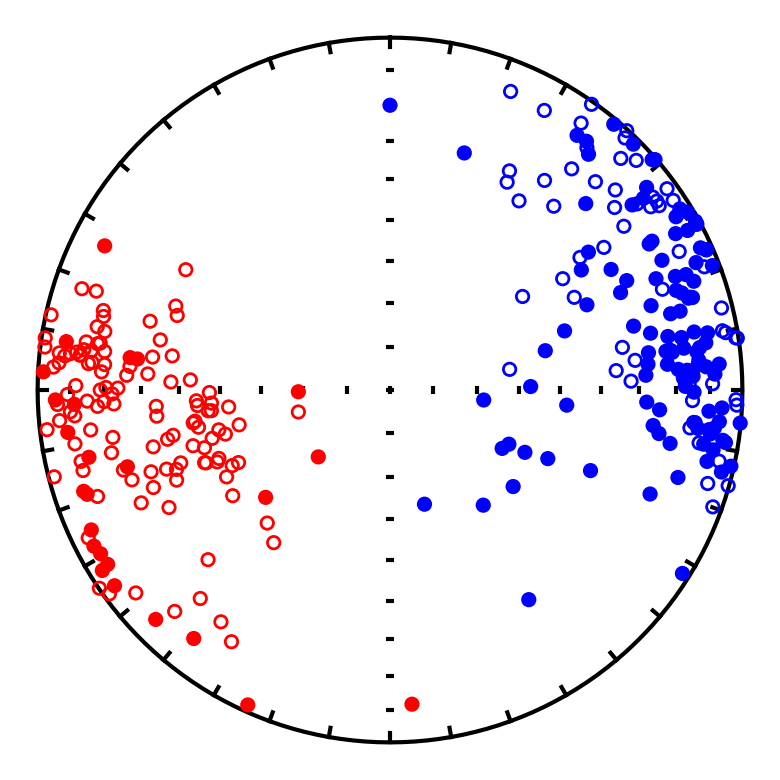

In [4]:
rev = ipmag.reversal_test_MM1990(di_block=sel[['dir_dec', 'dir_inc']].to_numpy(),
                                 plot_stereo=True)

## E/I inclination-shallowing correction

`ipmag.find_ei` searches for the flattening factor whose corrected directional
distribution matches the elongation predicted by the TK03.GAD field model
(Tauxe & Kent, 2004). This bootstrap takes ~1 minute.

Bootstrapping.... be patient

The original inclination was: 14.34

The corrected inclination is: 21.98
with bootstrapped confidence bounds of: 17.12 to 26.72
and elongation parameter of: 2.44
The flattening factor is: 0.64
with bootstrapped confidence bounds of: 0.83 to 0.51

E/I flattening factor f = 0.64


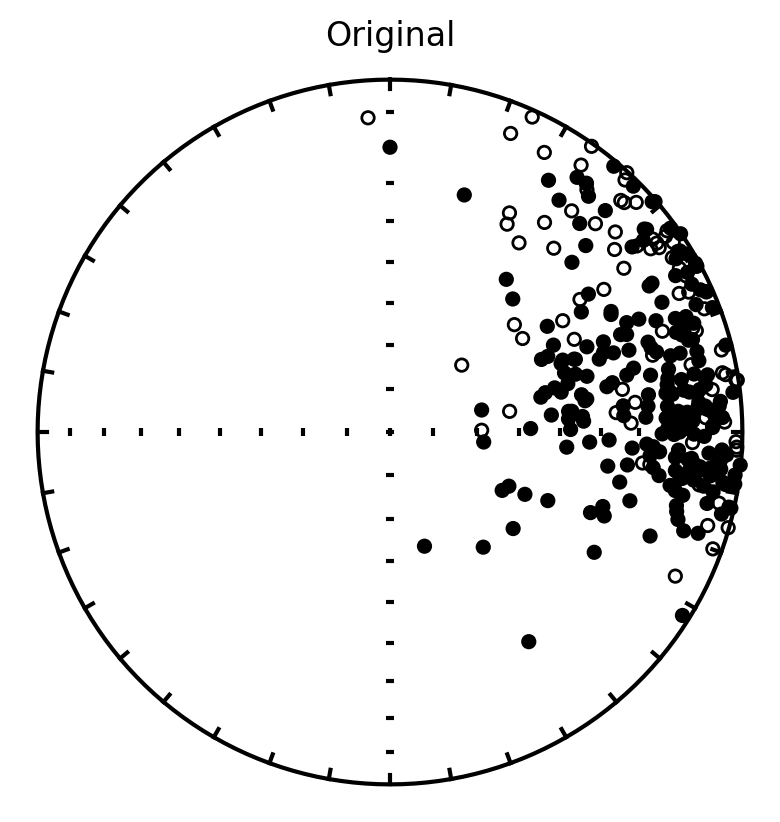

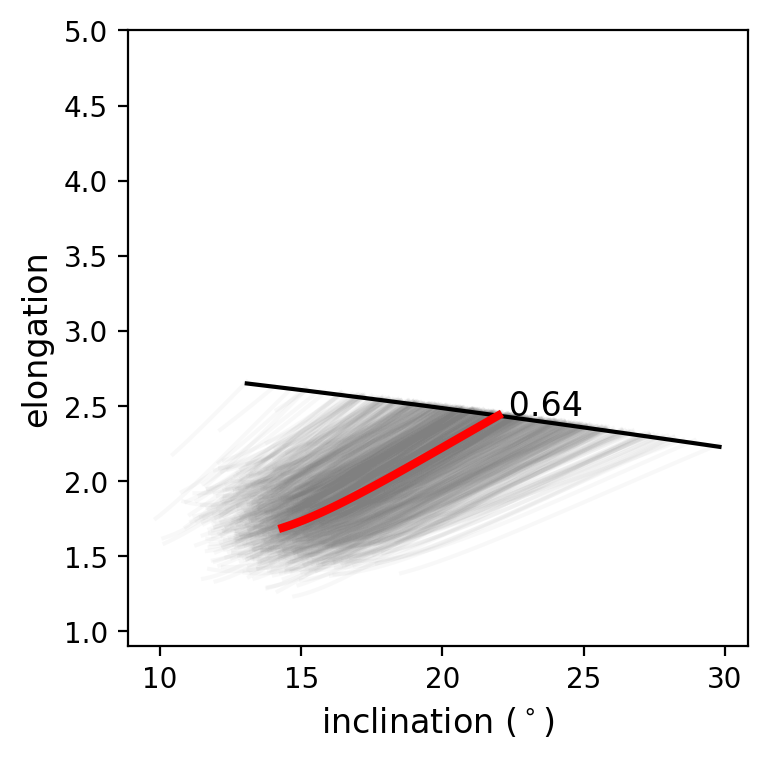

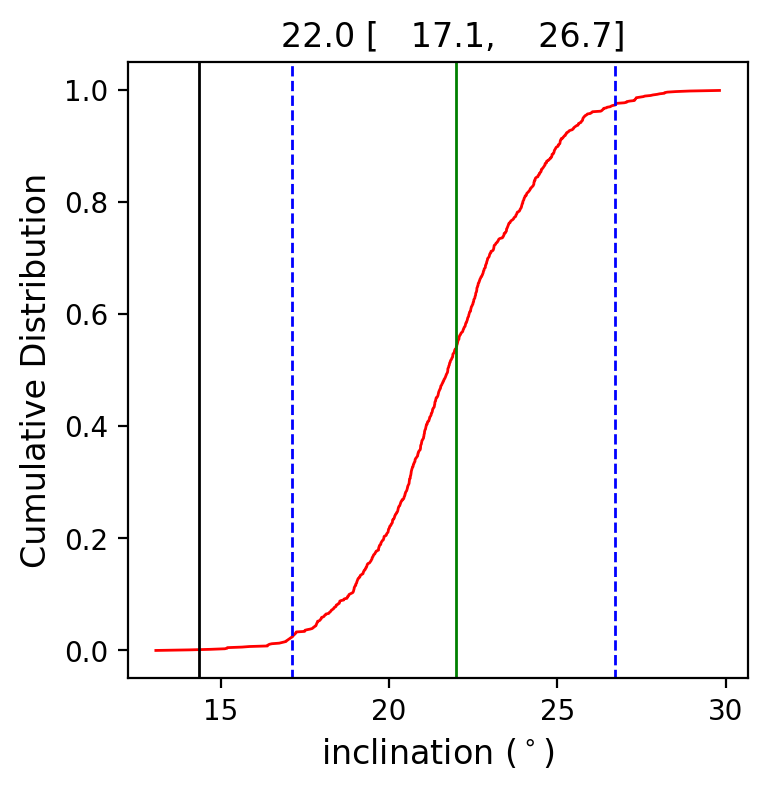

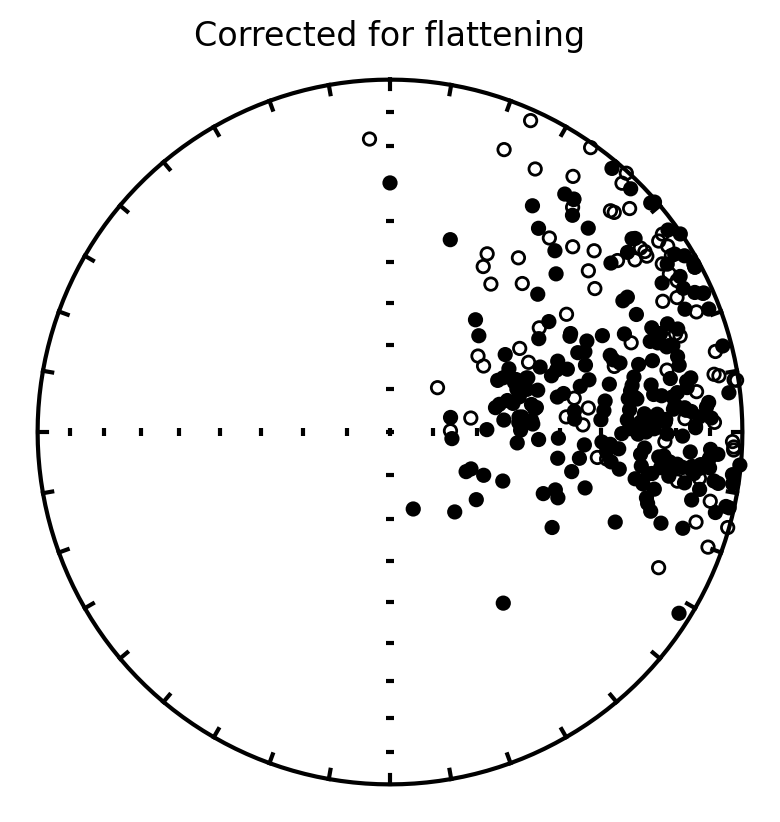

In [5]:
unified = pmag.flip(ipmag.make_di_block(sel['dir_dec'].tolist(),
                                       sel['dir_inc'].tolist()), combine=True)
ei_result = ipmag.find_ei(np.array(unified), nb=1000, return_values=True, save=False)
f_factor = round(float(ei_result[0]), 2)
print(f'\nE/I flattening factor f = {f_factor}')

In [6]:
# apply the E/I flattening factor and recompute the corrected direction and pole
sel_corr = sel.copy()
sel_corr['dir_inc'] = ipmag.unsquish(sel['dir_inc'].tolist(), f_factor)
sel_corr = ipmag.vgp_calc(sel_corr, tilt_correction='no', site_lon='lon', site_lat='lat',
                          dec_is='dir_dec', inc_is='dir_inc')

_, corr_dir = pt.compute_mean_direction(sel_corr, unify_polarity=True, flip=True)
print(f'Inclination-corrected mean direction (f = {f_factor}):')
ipmag.print_direction_mean(corr_dir)

_, corr_pole = pt.compute_mean_pole(sel_corr, unify_polarity=True, flip=True)
print(f'\nInclination-corrected pole (f = {f_factor}):')
ipmag.print_pole_mean(corr_pole)

# Published Kent-ellipse uncertainty (Zhang et al., 2024); the Nordic format
# stores a single A95, so use the equal-area circular approximation.
zeta95, eta95 = 4.1, 3.1
a95_kent = pt.kent_a95_approx(zeta95, eta95)
print(f'\nKent ellipse (Zhang et al., 2024): zeta95={zeta95}, eta95={eta95}; '
      f'equal-area A95 approximation = {a95_kent:.1f}')
print(f'Published corrected pole: 16.9°S, 183.4°E')

Inclination-corrected mean direction (f = 0.64):
Dec: 257.2  Inc: -20.0
Number of directions in mean (n): 308
Angular radius of 95% confidence (a_95): 3.8
Precision parameter (k) estimate: 5.3

Inclination-corrected pole (f = 0.64):
Plon: 183.8  Plat: -16.8
Number of directions in mean (n): 308
Angular radius of 95% confidence (A_95): 3.0
Precision parameter (k) estimate: 7.9

Kent ellipse (Zhang et al., 2024): zeta95=4.1, eta95=3.1; equal-area A95 approximation = 3.6
Published corrected pole: 16.9°S, 183.4°E


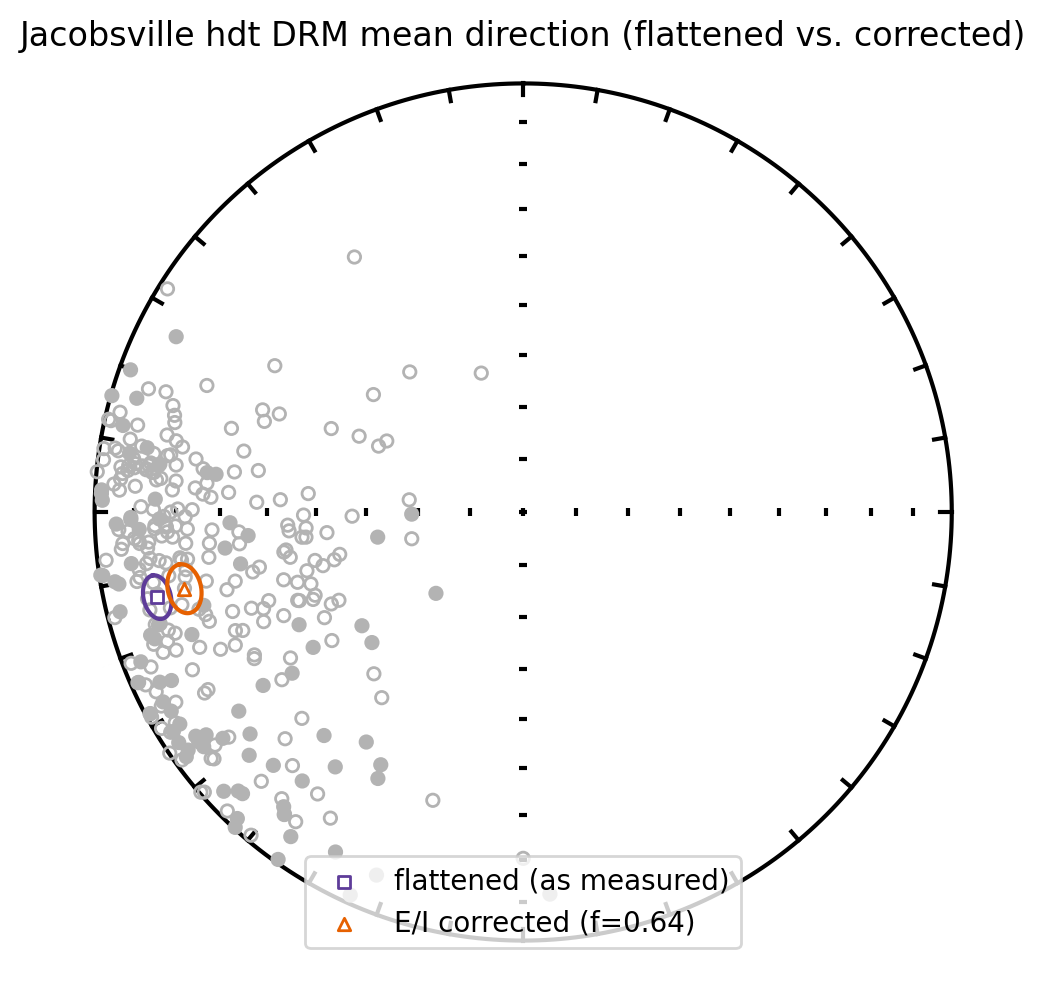

In [7]:
# flattened vs. inclination-corrected mean directions (reverse-polarity convention)
ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='#b3b3b3', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'],
                   color='#5e3c99', marker='s', label='flattened (as measured)')
ipmag.plot_di_mean(corr_dir['dec'], corr_dir['inc'], corr_dir['alpha95'],
                   color='#e66101', marker='^', label=f'E/I corrected (f={f_factor})')
plt.legend(loc='lower center')
plt.title('Jacobsville hdt DRM mean direction (flattened vs. corrected)')
plt.show()

## Pole in the context of the Laurentia APWP

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


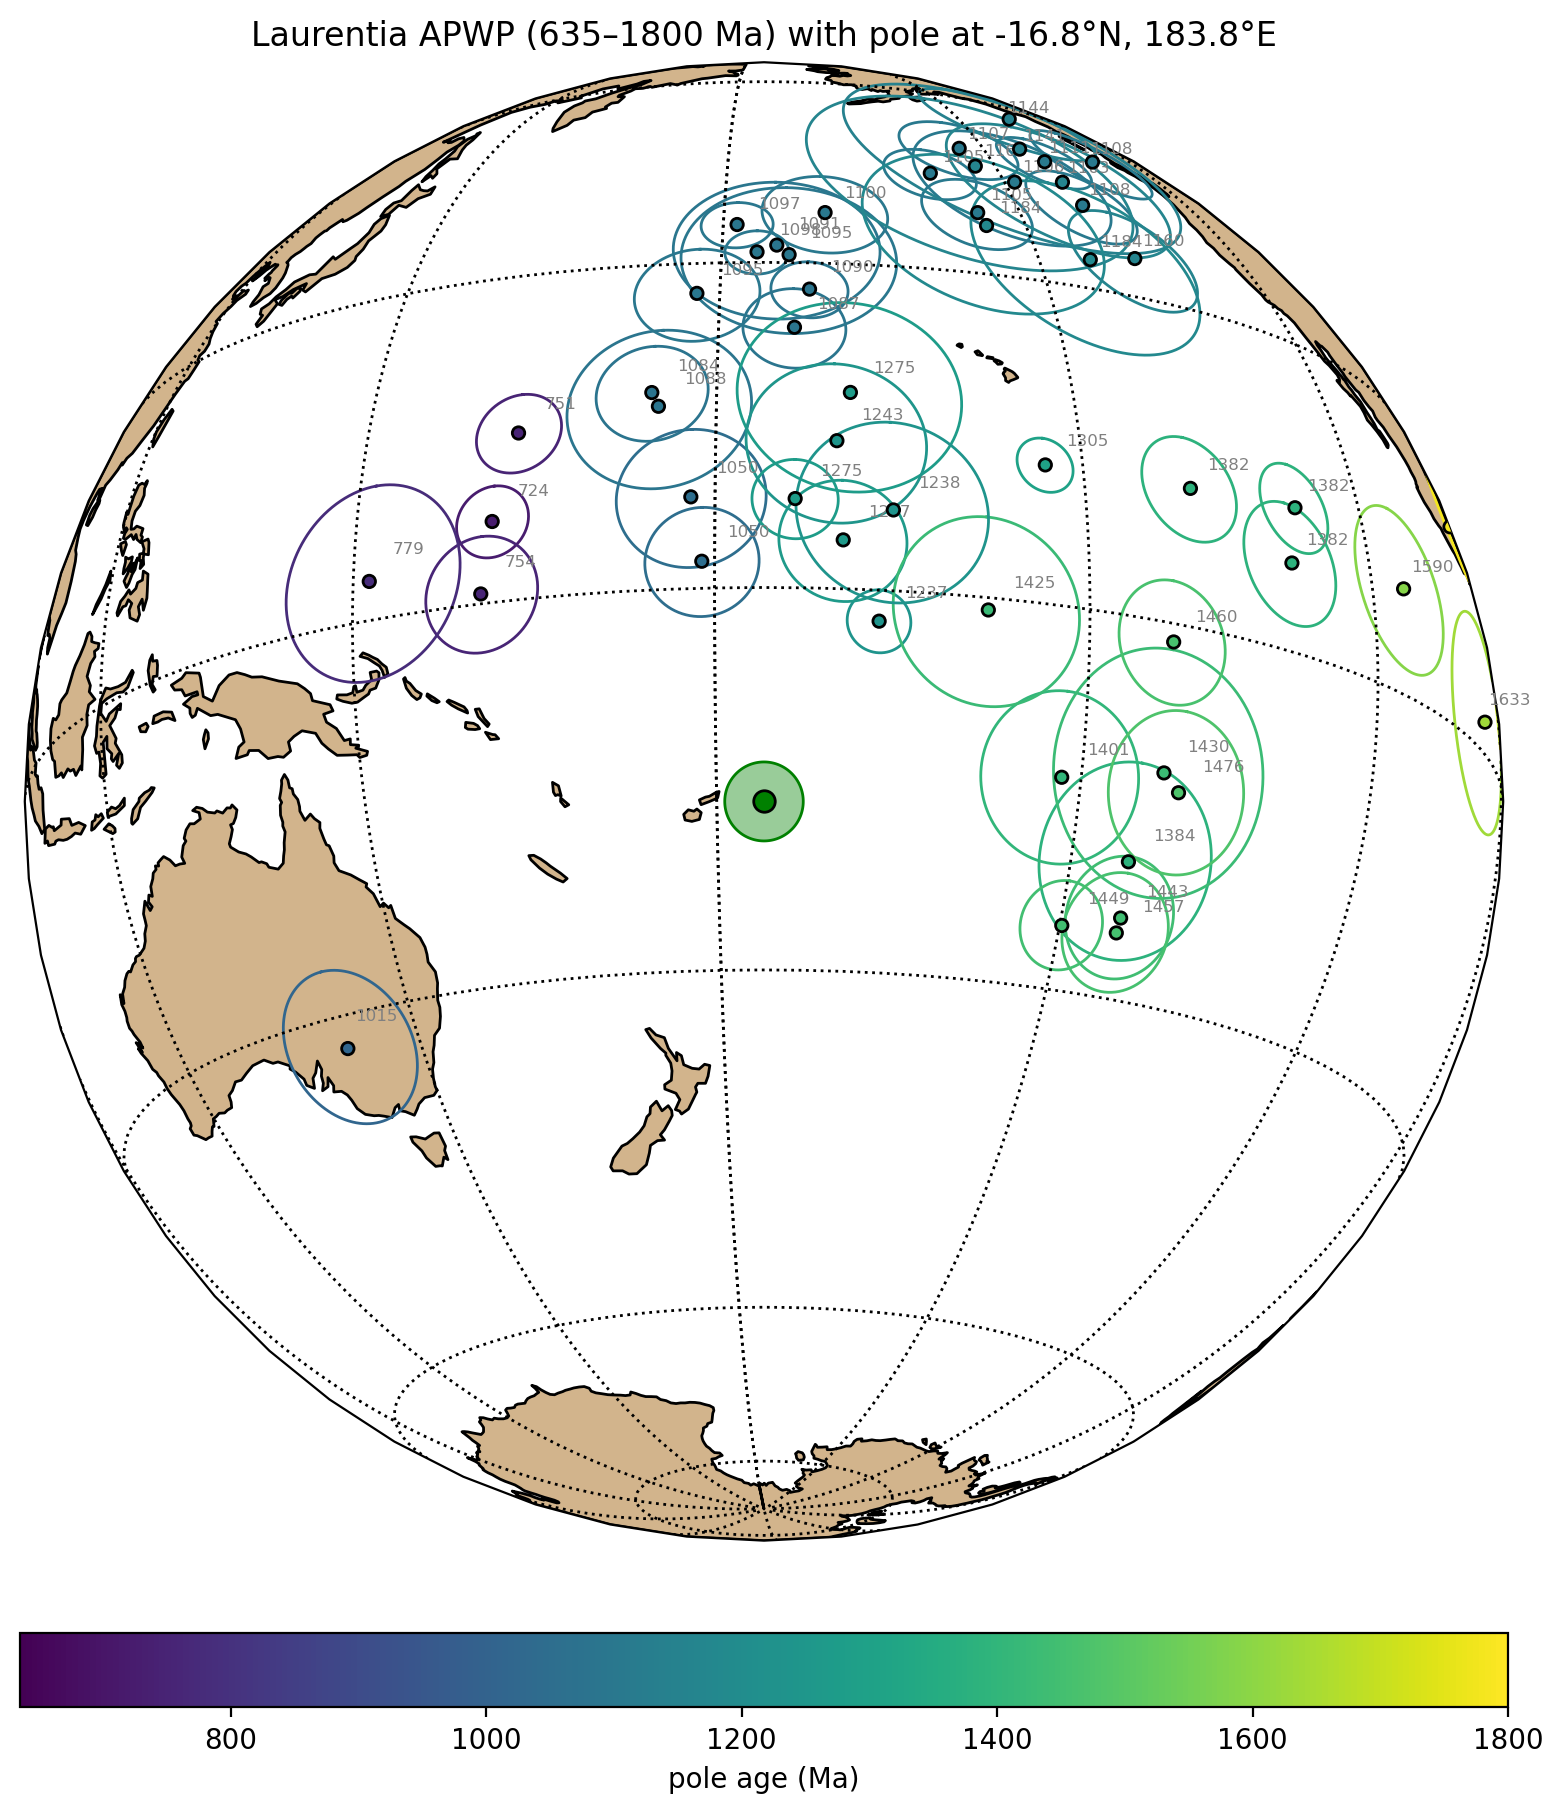

In [8]:
Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_poles = pt.plot_apwp_context(Laurentia_poles, corr_pole['inc'], corr_pole['dec'], corr_pole['alpha95'], age_min=635, age_max=1800, projection='orthographic', central_longitude=corr_pole['dec'], central_latitude=corr_pole['inc'])
plt.show()

## R2: Deenen test and PSV sampling

PSV sampling is supported by the capture of multiple polarity reversals across
five sections sampled for stratigraphic coverage. Note that the corrected pole's
A95 sits slightly above the Deenen et al. (2011) upper bound for this large N
(~2.2° for N ≈ 307), indicating modest over-dispersion — discussed by Zhang et
al. (2024) and not treated as failing R2.

A_95 of 3.0 is too large for Deenen criteria of 2.2 for this number of sites


<AxesSubplot:title={'center':'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

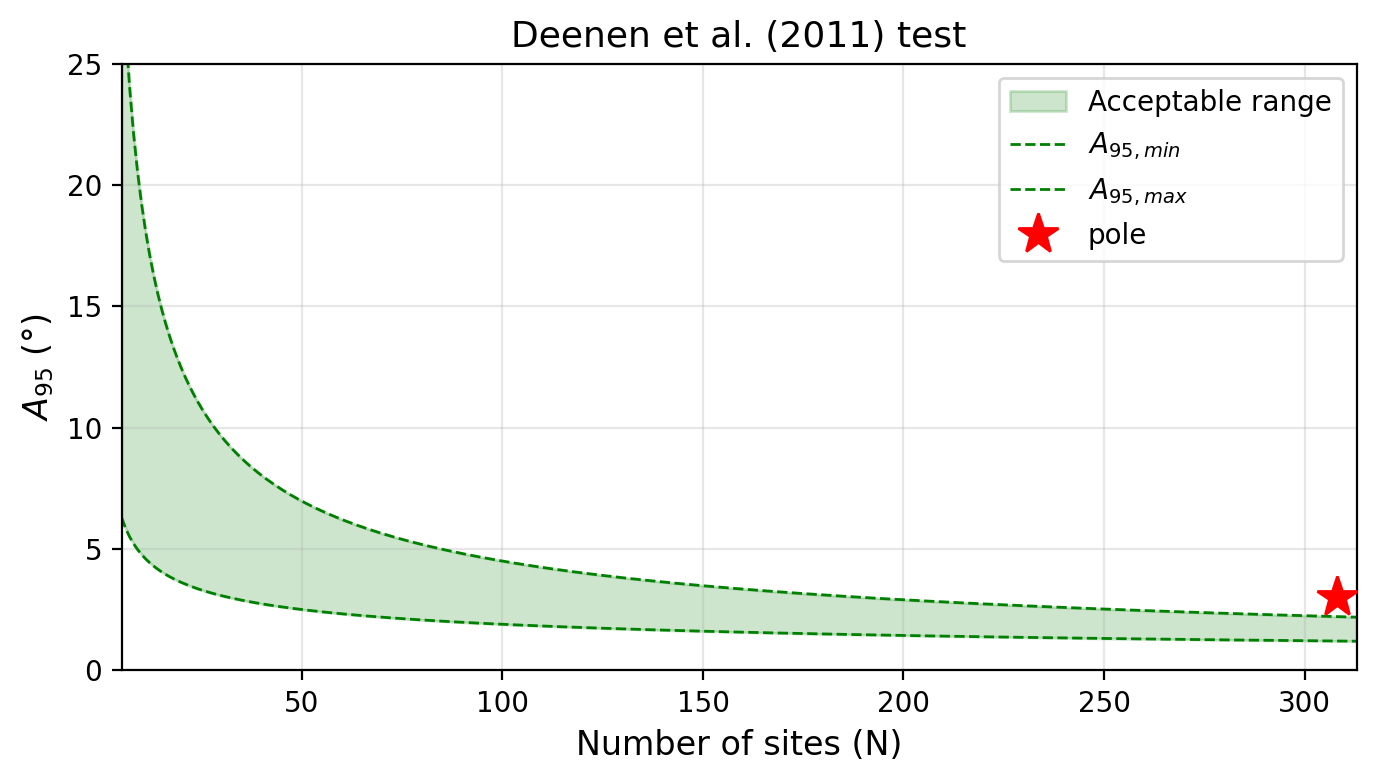

In [9]:
pt.Deenen_test(corr_pole['n'], corr_pole['alpha95'])
pt.plot_Deenen_test(corr_pole)

## R7: Comparison with younger Laurentia poles

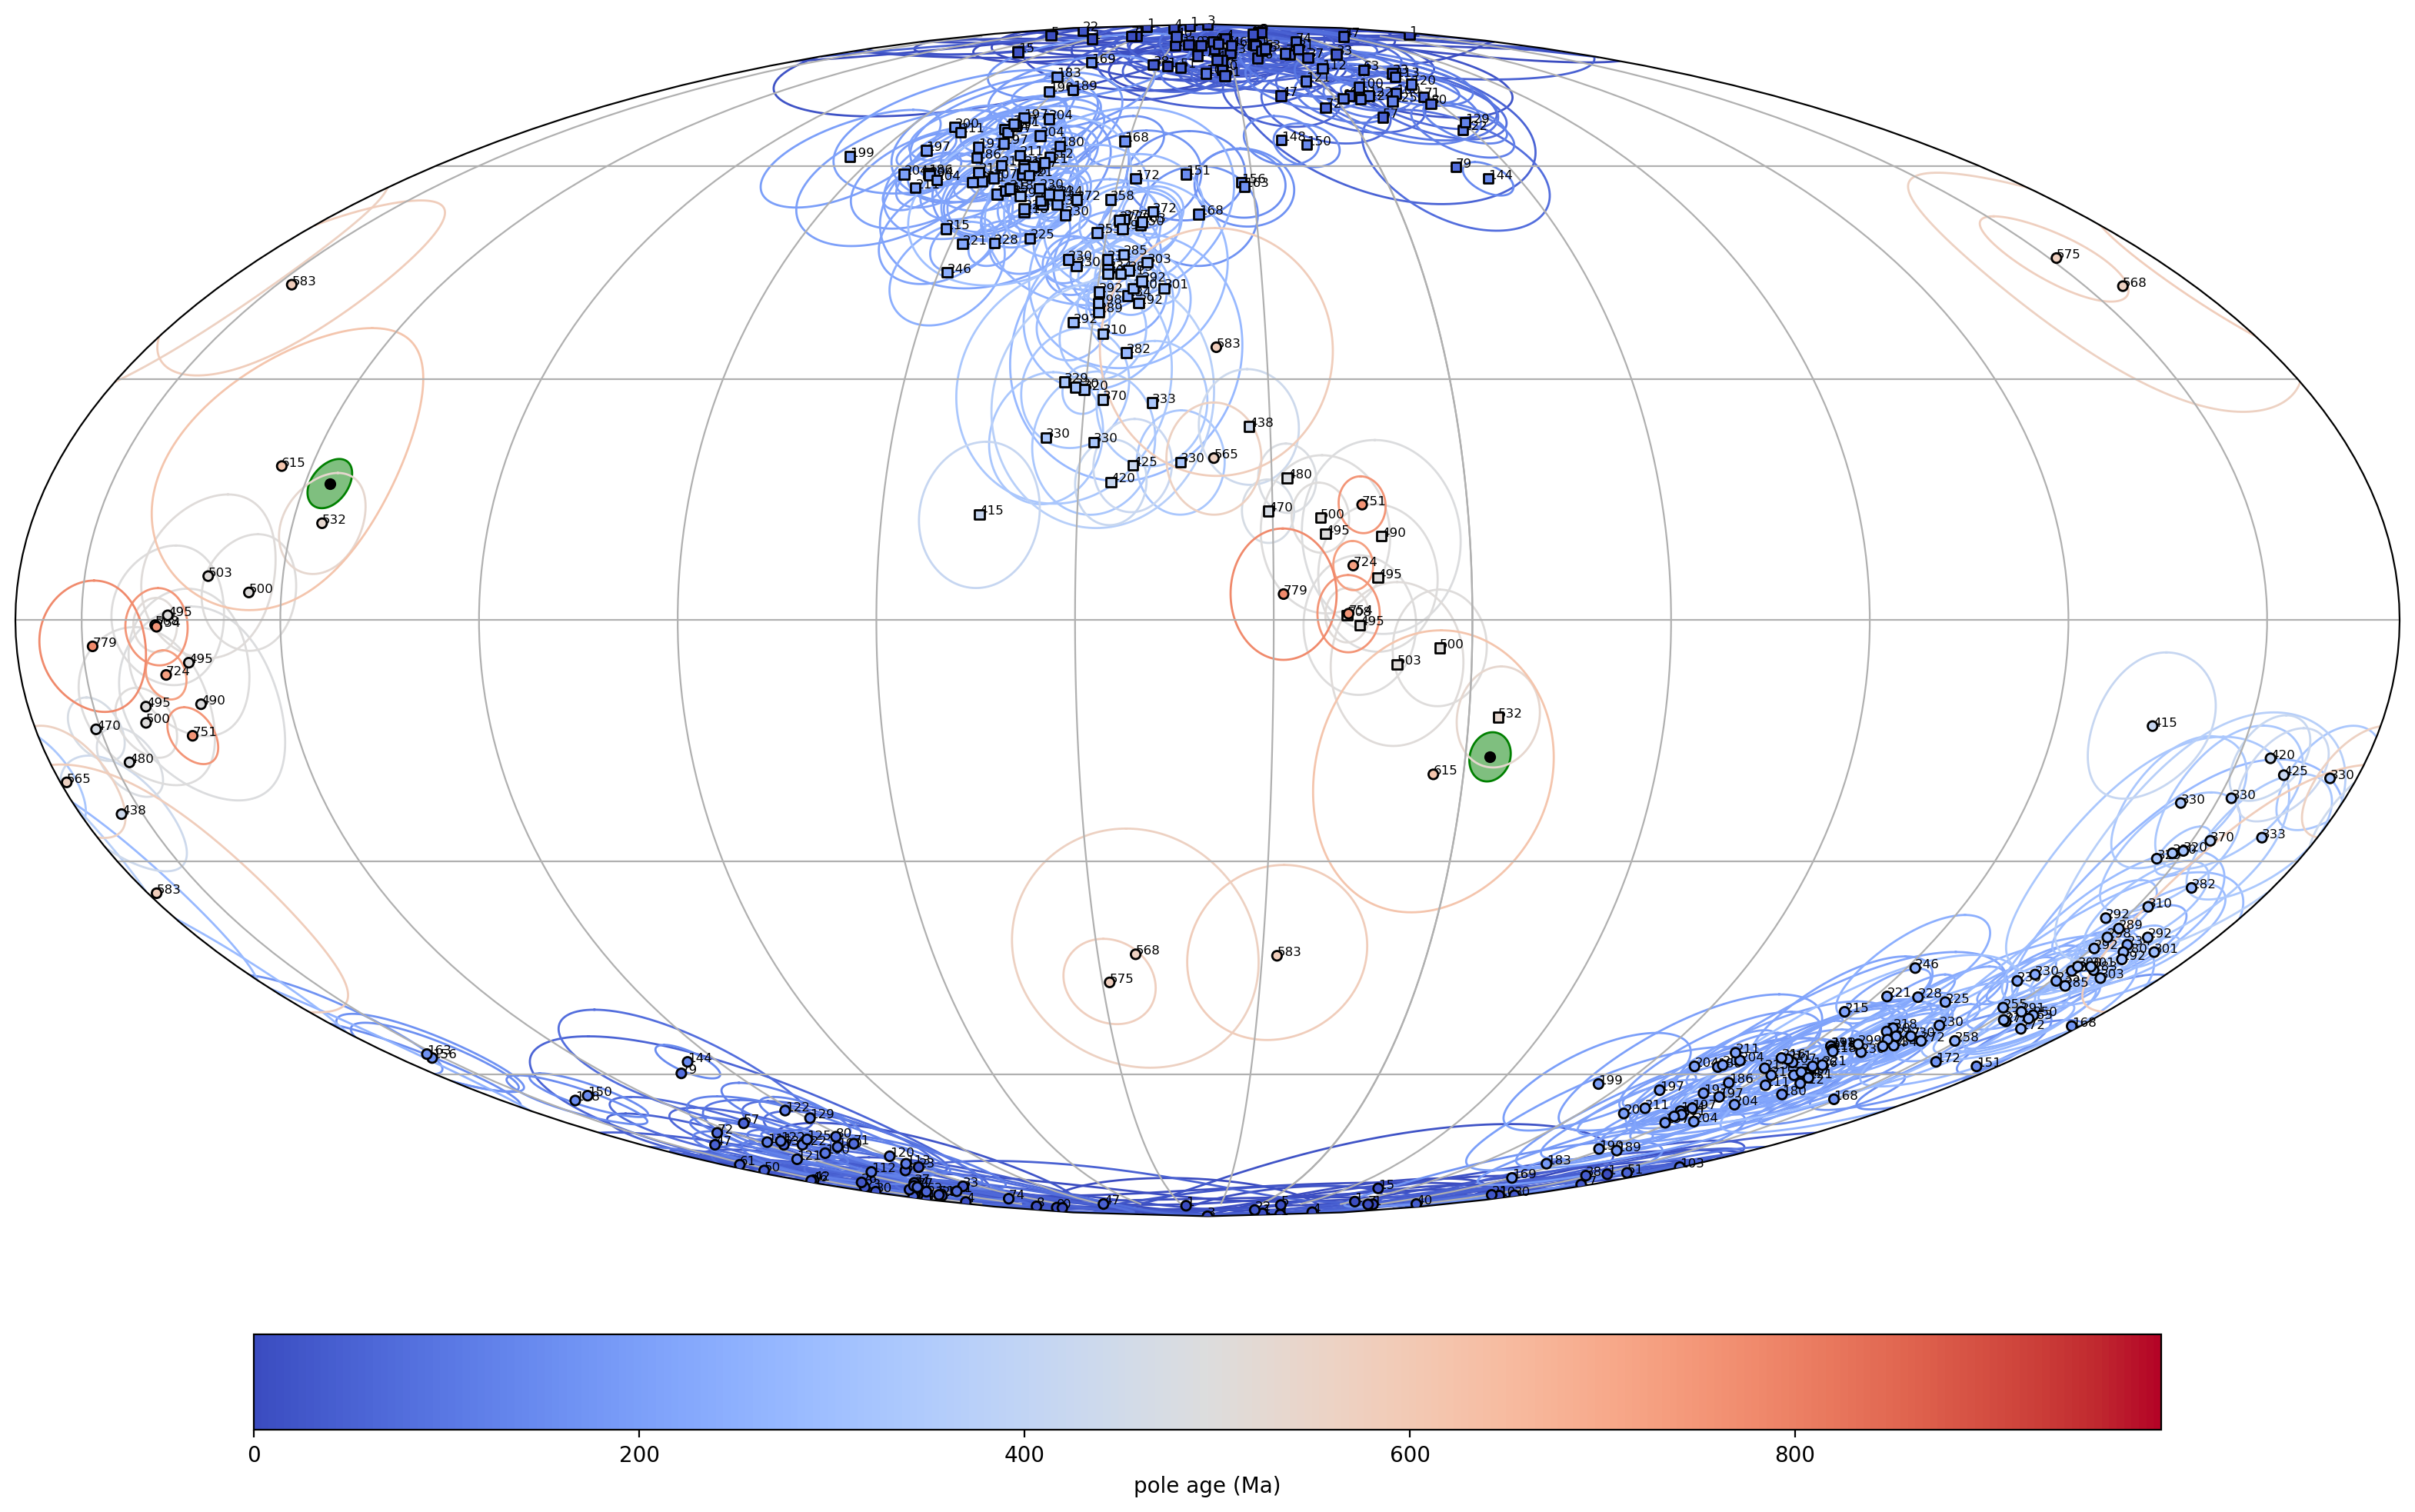

<GeoAxesSubplot:>

In [10]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Jacobsville Formation',
                     Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=corr_pole['inc'], pole_plon=corr_pole['dec'],
                     pole_A95=corr_pole['alpha95'], pole_age=990)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | Maximum depositional age constrained by CA-ID-TIMS detrital zircon dates of 1,003.21 ± 2.23 Ma (Agate Falls) and 992.51 ± 0.64 Ma (Sandstone Creek; Hodgin et al., 2022). Minimum age from U-Pb calcite (985.5 ± 35.8 Ma) in Keweenaw Fault breccia and from Rigolet-phase Grenvillian deformation (ca. 1,010–980 Ma; Swanson-Hysell et al., 2023). Best estimate ca. 990 Ma; full plausible range 1,000–980 Ma falls within ± 15 Ma if we consider Keweenaw Fault to be dominantly the result of Grenvillian contraction. |
| 2 | Techniques and statistical analysis | **1** | (a) High-resolution stepwise thermal demagnetization (5–2°C steps approaching the Néel temperature of hematite; lack of AF is appropriate for hematite-bearing lithologies). (b) PCA component fits using PmagPy (Kirschvink, 1980). (c) PSV averaging supported by capture of ≥9 polarity reversals at Dover Creek (and additional reversals at Agate Falls, Natural Wall, Hammel Creek), n = 307 specimen-sites distributed across 5 sections sampled for vertical stratigraphic coverage. One potential issue is that the A95 of the pole for a N=307 is a bit above the Deenen cut-off of 2.2º for this many sites indicating some over-dispersion.|
| 3 | Magnetic mineralogy characterized | **1** | Two hematite populations identified by unblocking temperature: pigmentary hematite (CRM, removed by ~640–655°C) and detrital hematite (DRM, up to ~689°C, near Néel temperature). Grain-size and unblocking-temperature distinctions documented (text and Figure S1) and consistent with prior work on Jacobsville (Roy & Robertson, 1978) and red-bed component-separation literature (Collinson, 1974; Tauxe et al., 1980; Bilardello & Kodama, 2010). |
| 4 | Field tests constrain age of magnetization | **1** | (a) Positive intraformational conglomerate tests on siltstone intraclasts at Agate Falls (n = 5) and Dover Creek (n = 22): high-temperature DRM directions are dispersed and pass the Watson (1956) randomness test at 95% confidence, while the mid-temperature CRM directions are well-grouped (negative on the CRM, positive on the DRM). (b) Positive bootstrap fold test (Tauxe & Watson, 1994) at the Snake Creek tributary section across the Keweenaw Fault drag fold: best grouping at 93–143% unfolding (95% CI includes 100%). The CRM fails the fold test, supporting it as a post-tilt secondary overprint. |
| 5 | Structural control / tectonic coherence | **1** | Pole is from autochthonous Laurentian cratonic strata and is corrected for inclination shallowing. |
| 6 | Presence of reversals | **0** | Dual-polarity directions are present (normal westerly, reversed easterly), but the McFadden & McElhinny (1990) reversal test fails: γ_o = 15.9° exceeds γ_c = 7.5°. Authors discuss several plausible causes (under-sampling of normal polarity at Snake Creek tributary, possible plate motion between polarity intervals, residual CRM contamination, or non-modern field dispersion). No formal H&R (2018b) common-mean test reported. |
| 7 | No resemblance to younger poles | **1** | The pole is distinct from all younger poles. Although it would pass regardless, given the positive intraclast conglomerate test . |
| | **Total R-score** | **6/7** | |

## Nordic workshop ranking

Proposed: **A**. The Jacobsville pole is a new, well-determined inclination-
corrected pole (Zhang et al., 2024) that extends the Laurentia path into the
late Tonian, with strong field tests (R4) and a tight age (R1); only the failed
reversal test (R6) keeps it from 7/7. The Nordic summary records the
as-measured (flattened) pole in the main block and the E/I-corrected pole in the
f-block, with the corrected A95 taken as the equal-area approximation of the
published Kent ellipse.

In [11]:
# Nordic summary: main block = flattened; f-block = E/I-corrected (A95 from Kent ellipse).
sites_df = pd.DataFrame({'dir_tilt_correction': [100] * len(sel),
                         'dir_n_samples': [1] * len(sel)})
corr_pole_nordic = {'dec': corr_pole['dec'], 'inc': corr_pole['inc'],
                    'alpha95': a95_kent}   # A95 = sqrt(zeta95*eta95) from Kent ellipse

Jacobsville_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Jacobsville Formation',
    sites=sites_df,
    dir_mean=dir_mean,
    pole_mean=flat_pole,
    study_lon=float(sel['lon'].mean()),
    study_lat=float(sel['lat'].mean()),
    lithology='sedimentary',
    component_comment='High-temperature detrital hematite remanent magnetization (DRM)',
    tests='g+ (positive intraformational conglomerate tests, Agate Falls & Dover Creek) and f+ (positive bootstrap fold test, Snake Creek); reversal test fails (Zhang et al., 2024)',
    magic_id='19780',
    R1=1,
    R2=1,
    R3=1,
    R4='Gf',
    R5=1,
    R6=0,
    R7=1,
    Grade='A',
    nominal_age=990,
    lomagage=980,
    himagage=1000,
    REF_method='Maximum depositional age from CA-ID-TIMS detrital zircon 1003.21 ± 2.23 and 992.51 ± 0.64 Ma; minimum age from Rigolet-phase deformation and U-Pb calcite (Hodgin et al., 2022). Best estimate ca. 990 Ma.',
    POLE_AUTHORS='Zhang, Y., Hodgin, E. B., Alemu, T., Pierce, J., Fuentes, A., & Swanson-Hysell, N. L.',
    YEAR=2024,
    JOURNAL='Tectonics',
    VOLUME=43,
    VPAGES='e2023TC007866',
    TITLE='Tracking Rodinia into the Neoproterozoic: new paleomagnetic constraints from the Jacobsville Formation',
    COMMENT=pt.corrected_pole_note('E/I (Tauxe & Kent, 2004)', corr_pole['inc'], corr_pole['dec'], f=f_factor, zeta95=zeta95, eta95=eta95, monte_carlo='Pierce et al. (2022) Monte Carlo') + ' Pole recreated from the hdt detrital-hematite directions (12 sections, n=308; paper n=307). Nordic main and f-blocks both use the blanket sedimentary f=0.6 inclination correction.'
)
Jacobsville_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Jacobsville Formation,MagIC:19780,High-temperature detrital hematite remanent ma...,g+ (positive intraformational conglomerate tes...,100,47.3,-88.2,308,308,...,1000,Maximum depositional age from CA-ID-TIMS detri...,Jacobsville Formation,"Zhang, Y., Hodgin, E. B., Alemu, T., Pierce, J...",2024,Tectonics,43,e2023TC007866,Tracking Rodinia into the Neoproterozoic: new ...,Study inclination-corrected pole - E/I (Tauxe ...


In [12]:
pt.save_nordic_summary(Jacobsville_summary, '990_Jacobsville')

'../data/nordic_summaries/990_Jacobsville.csv'